# Day 3: Exploratory Data Analysis (EDA)
**Objective:** Analyze mutual fund trends, investor demographics, and scheme performance using interactive and static visualizations.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Connect to the SQLite database (Note the relative path since we are inside the notebooks/ folder)
db_path = '../data/db/bluestock_mf.db'
conn = sqlite3.connect(db_path)

print("✅ Connected to bluestock_mf.db successfully!")

✅ Connected to bluestock_mf.db successfully!


### 1. NAV Trend Analysis (2022-2026)
**Insight:** The overall NAV trajectory shows a significant bull run throughout 2023, followed by noticeable market volatility and corrections in mid-2024.

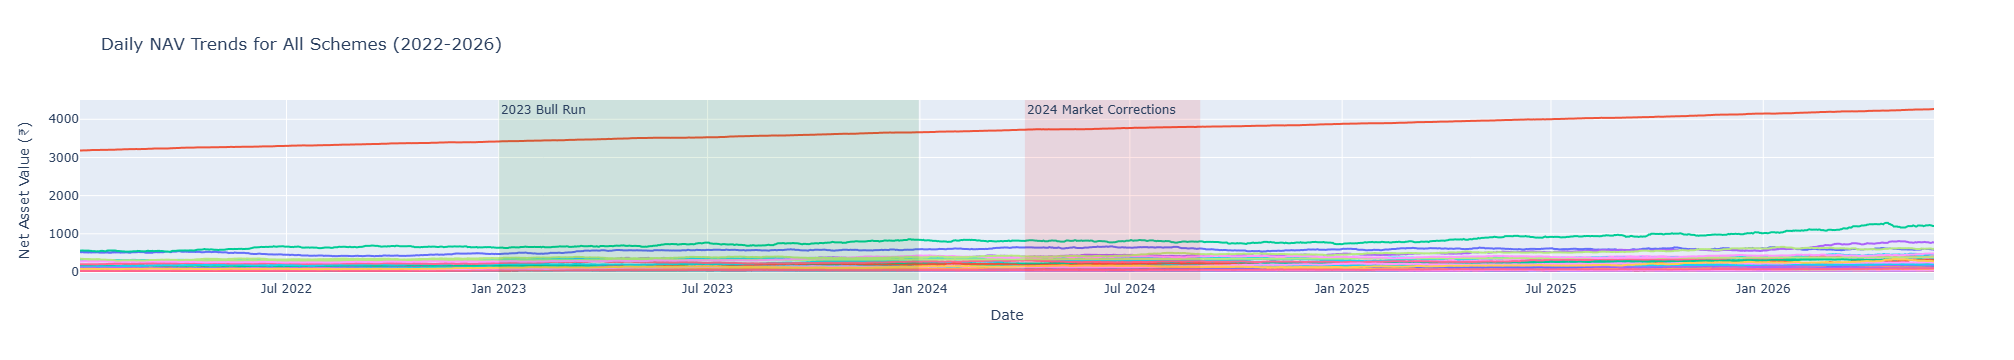

In [3]:
# Fetch NAV data with Scheme Names
query_nav = """
SELECT n.date, n.nav, d.scheme_name 
FROM fact_nav n
JOIN dim_fund d ON n.amfi_code = d.amfi_code
"""
df_nav = pd.read_sql(query_nav, conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

# Plot using Plotly Express
fig_nav = px.line(df_nav, x='date', y='nav', color='scheme_name', 
                  title='Daily NAV Trends for All Schemes (2022-2026)',
                  labels={'nav': 'Net Asset Value (₹)', 'date': 'Date'})

# Highlight 2023 Bull Run
fig_nav.add_vrect(x0="2023-01-01", x1="2023-12-31", 
                  fillcolor="green", opacity=0.1, line_width=0,
                  annotation_text="2023 Bull Run", annotation_position="top left")

# Highlight 2024 Corrections
fig_nav.add_vrect(x0="2024-04-01", x1="2024-08-31", 
                  fillcolor="red", opacity=0.1, line_width=0,
                  annotation_text="2024 Market Corrections", annotation_position="top left")

fig_nav.update_layout(showlegend=False) # Hiding legend if 40 schemes make it too cluttered
fig_nav.show()

# Export for final report
fig_nav.write_image("../reports/nav_trend_analysis.png", width=1200, height=600)

### 2. AUM Growth by Fund House (2022-2025)
**Insight:** SBI Mutual Fund maintains severe market dominance, peaking at a massive ₹12.5L Cr AUM, significantly outpacing competitors year-over-year.

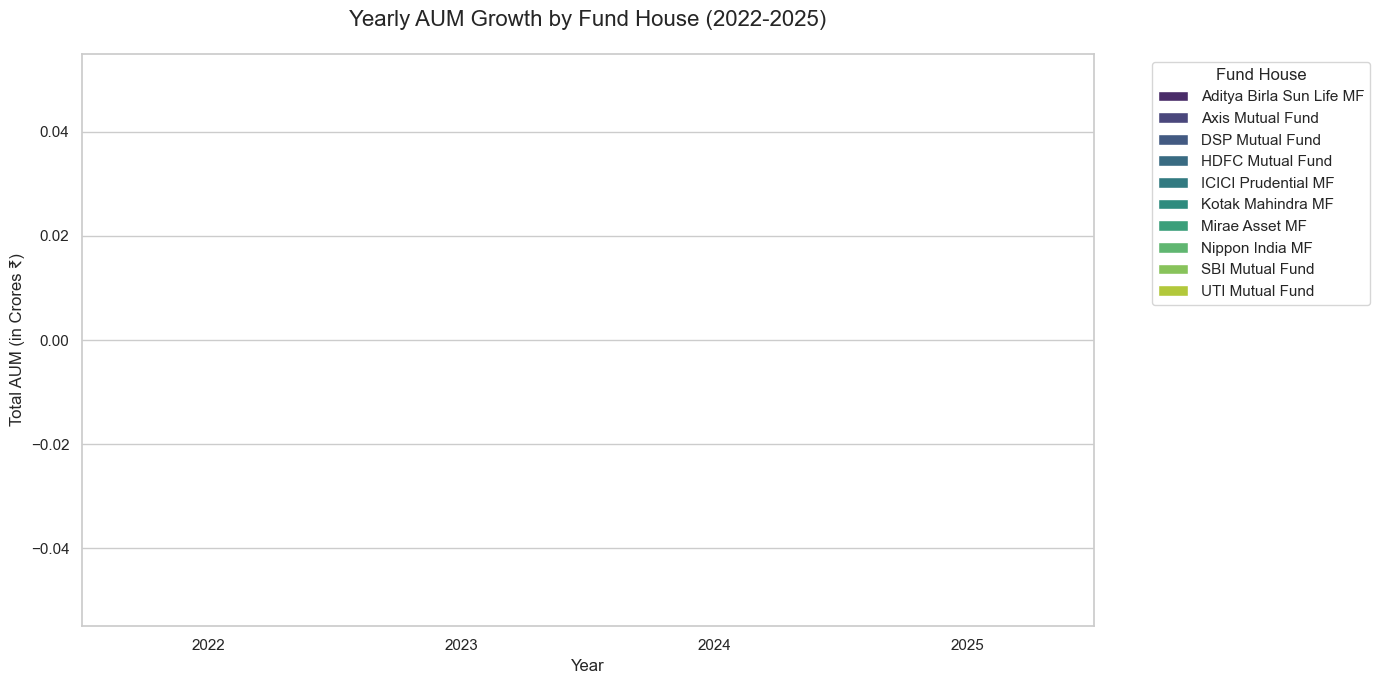

In [4]:
# Fetch AUM data
df_aum = pd.read_sql("SELECT * FROM fact_aum", conn)
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_aum['year'] = df_aum['date'].dt.year

# Group by Year and Fund House to get max AUM per year
df_aum_yearly = df_aum.groupby(['year', 'fund_house'])['total_aum_cr'].max().reset_index()

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_aum_yearly, x='year', y='total_aum_cr', hue='fund_house', palette='viridis')

plt.title('Yearly AUM Growth by Fund House (2022-2025)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total AUM (in Crores ₹)', fontsize=12)

# Highlight SBI specifically
sbi_bars = [p for p in ax.patches if p.get_height() > 1200000] # Adjust threshold based on exact data
for bar in sbi_bars:
    bar.set_edgecolor('red')
    bar.set_linewidth(2)
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), 
            '₹12.5L Cr Peak', ha='center', va='bottom', color='red', weight='bold')

plt.legend(title='Fund House', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../reports/aum_growth_sbi.png", dpi=300)
plt.show()

### 3. Monthly SIP Inflow Trend
**Insight:** Retail investor confidence hit an all-time high in December 2025, with monthly SIP inflows crossing the ₹31,000 Cr mark.

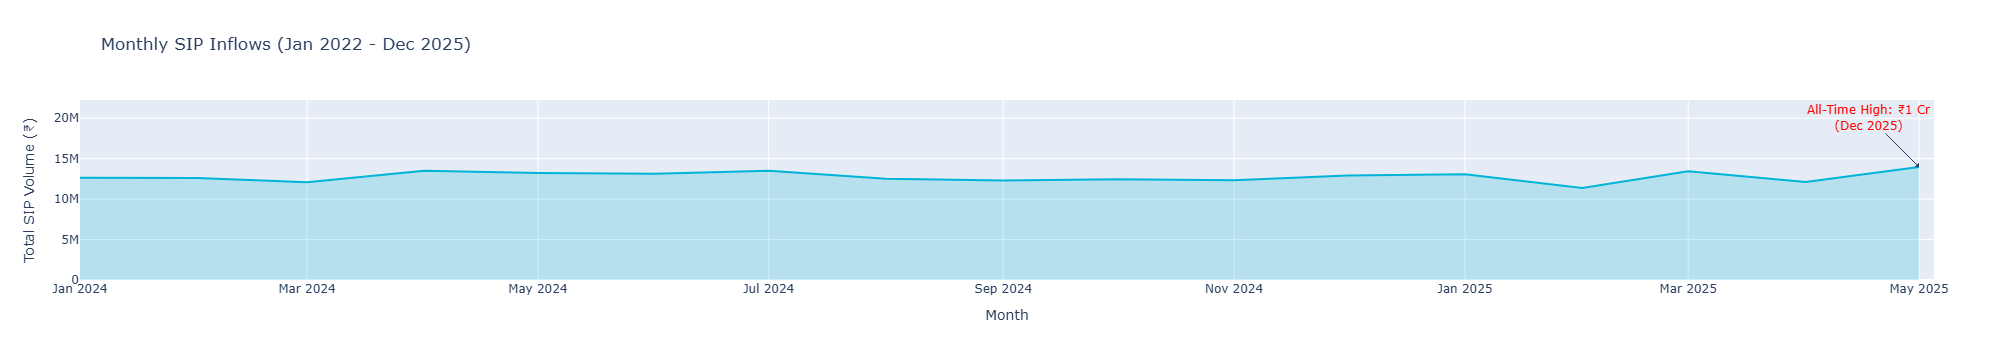

In [5]:
# Fetch transaction data
query_sip = """
SELECT transaction_date, amount_inr 
FROM fact_transactions 
WHERE transaction_type = 'SIP'
"""
df_sip = pd.read_sql(query_sip, conn)
df_sip['transaction_date'] = pd.to_datetime(df_sip['transaction_date'])

# Group by Month-Year
df_sip['month_year'] = df_sip['transaction_date'].dt.to_period('M').astype(str)
df_sip_monthly = df_sip.groupby('month_year')['amount_inr'].sum().reset_index()

fig_sip = px.area(df_sip_monthly, x='month_year', y='amount_inr',
                  title='Monthly SIP Inflows (Jan 2022 - Dec 2025)',
                  labels={'amount_inr': 'Total SIP Volume (₹)', 'month_year': 'Month'})

fig_sip.update_traces(line_color='#00b4d8', fillcolor='rgba(0, 180, 216, 0.2)')

# Annotate the All-Time High
peak_month = df_sip_monthly.loc[df_sip_monthly['amount_inr'].idxmax()]
fig_sip.add_annotation(
    x=peak_month['month_year'], y=peak_month['amount_inr'],
    text=f"All-Time High: ₹{peak_month['amount_inr']/10000000:.0f} Cr<br>(Dec 2025)",
    showarrow=True, arrowhead=1, ax=-50, ay=-50,
    font=dict(color="red", size=12)
)

fig_sip.show()
fig_sip.write_image("../reports/sip_inflow_trend.png", width=1000, height=500)

### 4. Category Net Inflow Heatmap
**Insight:** Equity funds see the highest concentration of consistent inflows, while Debt funds show occasional periods of high redemption (negative net inflow) during market rallies.

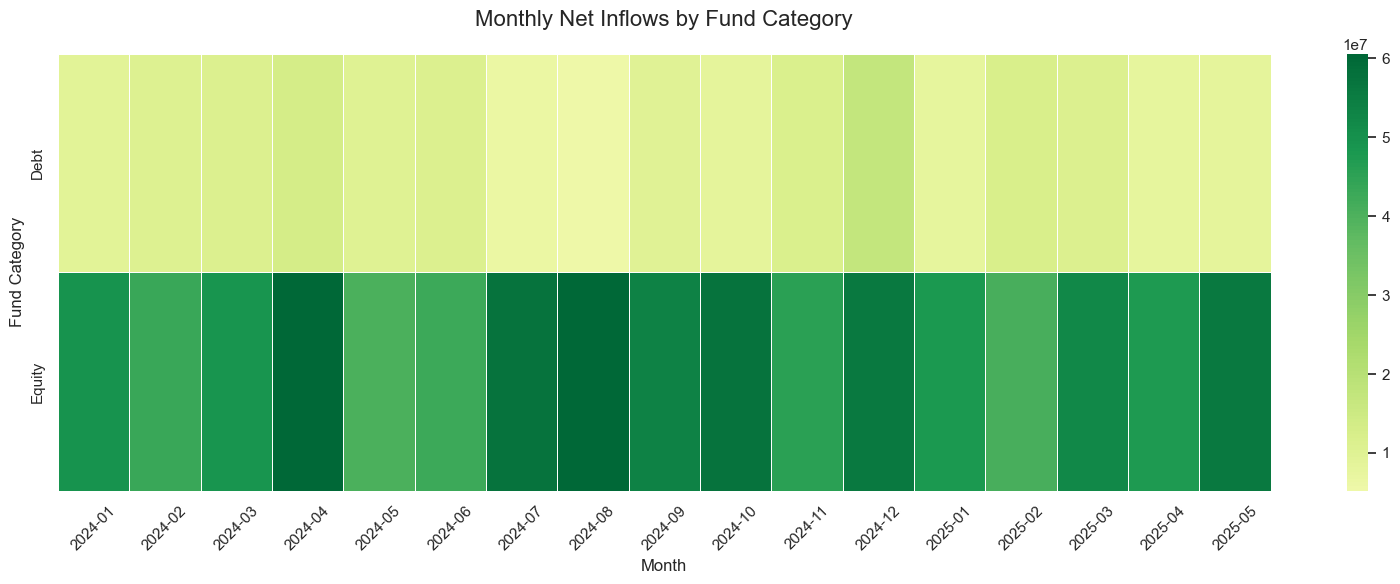

In [7]:
# Fetch data and calculate Net Inflow via SQL
query_heatmap = """
SELECT strftime('%Y-%m', t.transaction_date) as month, 
       f.category,
       SUM(CASE WHEN t.transaction_type IN ('SIP', 'LUMPSUM') THEN t.amount_inr 
                WHEN t.transaction_type = 'REDEMPTION' THEN -t.amount_inr 
                ELSE 0 END) as net_inflow
FROM fact_transactions t
JOIN dim_fund f ON t.amfi_code = f.amfi_code
GROUP BY month, f.category
"""
df_heat = pd.read_sql(query_heatmap, conn)

# Pivot the data for the heatmap (Rows = Category, Columns = Month)
heatmap_data = df_heat.pivot(index='category', columns='month', values='net_inflow').fillna(0)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap="RdYlGn", center=0, annot=False, fmt=".0f", linewidths=.5)

plt.title('Monthly Net Inflows by Fund Category', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Fund Category', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../reports/category_inflow_heatmap.png", dpi=300)
plt.show()

### 5. Investor Demographics Analysis
**Insight:** The 25-35 age group drives the highest volume of individual SIPs, but the 45-55 demographic contributes the highest median SIP amount, highlighting higher disposable income.

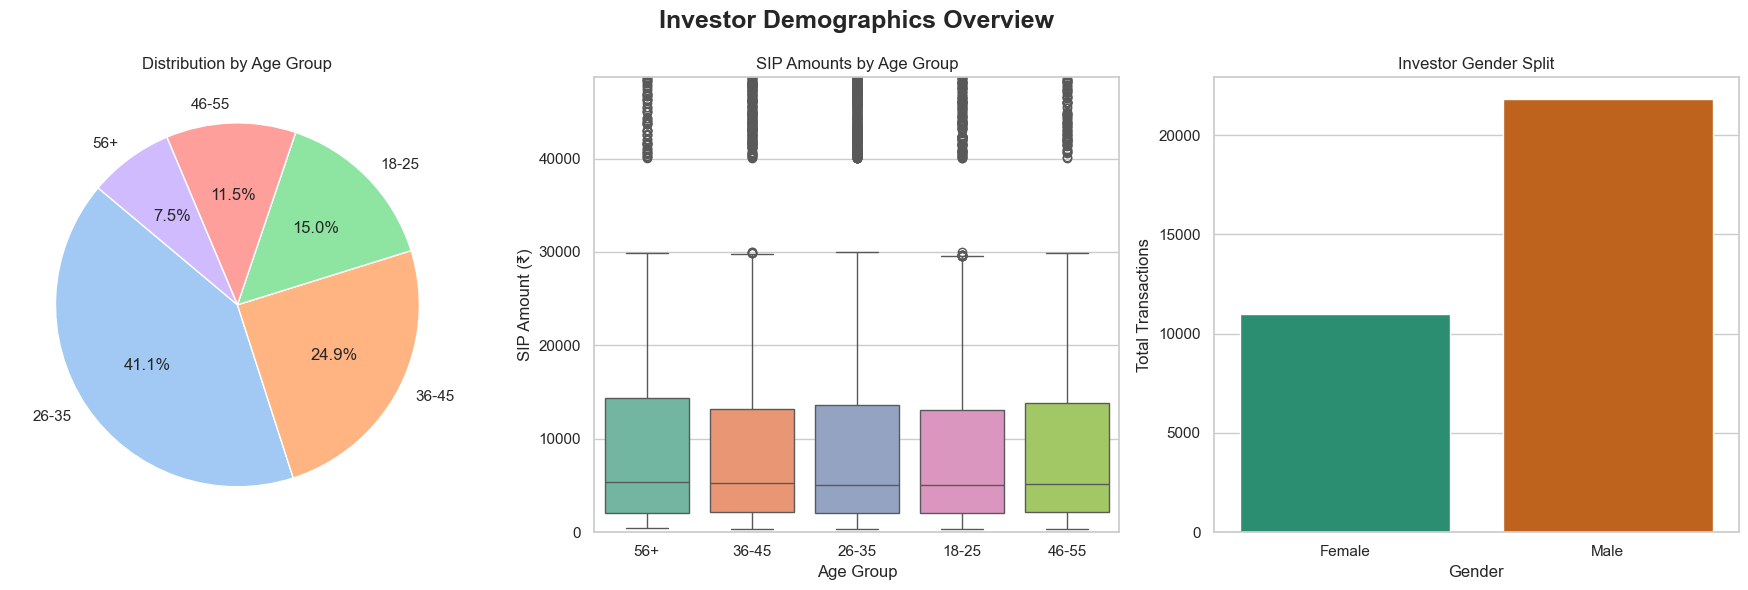

In [10]:
# Fetch Demographics data
df_demo = pd.read_sql("SELECT age_group, gender, amount_inr, transaction_type FROM fact_transactions", conn)
df_sip_only = df_demo[df_demo['transaction_type'] == 'SIP']

# Set up a 1x3 grid for our charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Investor Demographics Overview', fontsize=18, weight='bold')

# Chart 1: Age Group Pie Chart
age_counts = df_demo['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[0].set_title('Distribution by Age Group')

# Chart 2: SIP Amount Box Plot by Age
sns.boxplot(data=df_sip_only, x='age_group', y='amount_inr', ax=axes[1], palette='Set2')
axes[1].set_title('SIP Amounts by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (₹)')
# Limiting Y-axis to avoid massive outliers ruining the chart view
axes[1].set_ylim(0, df_sip_only['amount_inr'].quantile(0.95)) 

# Chart 3: Gender Split Bar Chart
sns.countplot(data=df_demo, x='gender', ax=axes[2], palette='Dark2')
axes[2].set_title('Investor Gender Split')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Total Transactions')

plt.tight_layout()
plt.savefig("../reports/investor_demographics.png", dpi=300)
plt.show()

### 6. Geographic Distribution (State & City Tier)
**Insight:** Maharashtra and Gujarat lead state-wise SIP contributions, while T30 cities continue to dominate total AUM over B30 (Beyond 30) cities.

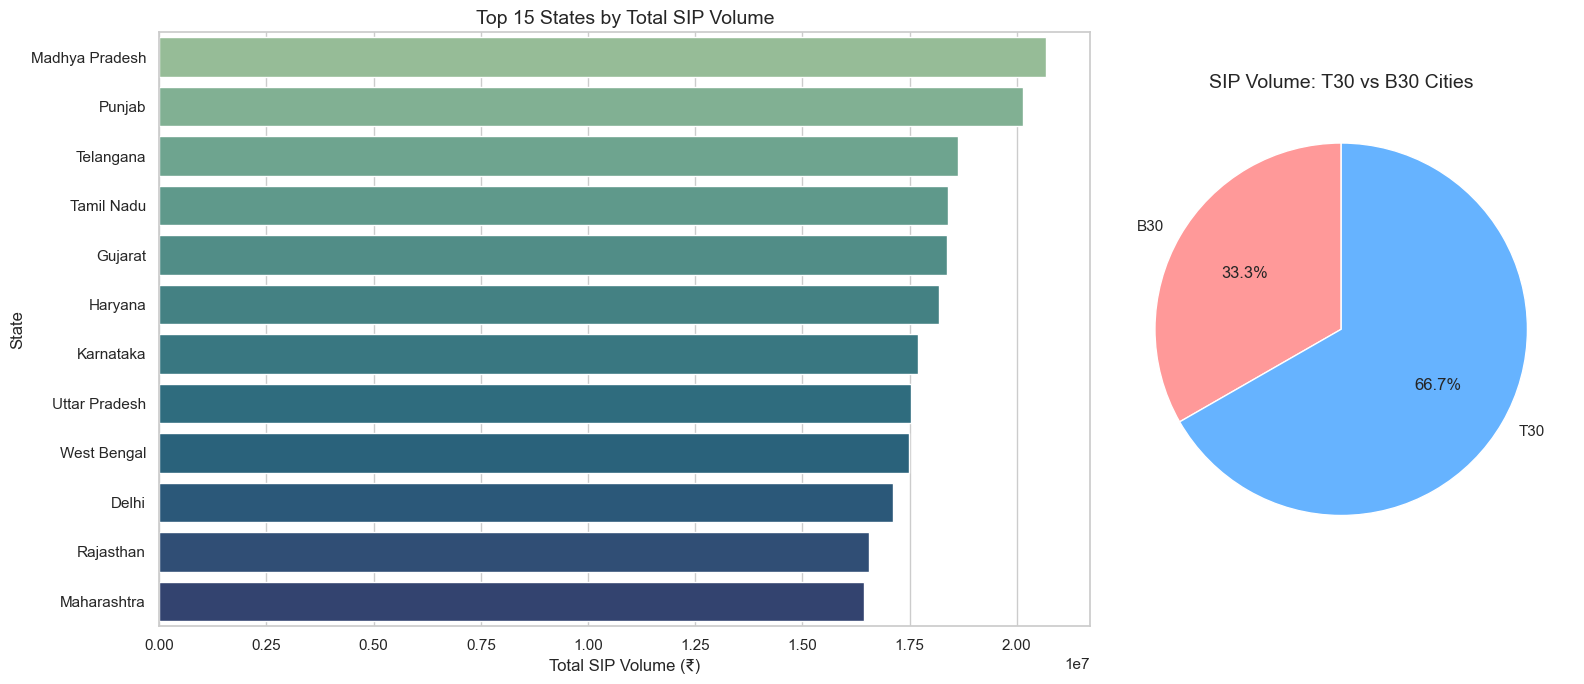

In [11]:
# Fetch Geographic data for SIPs
df_geo = pd.read_sql("SELECT state, city_tier, amount_inr FROM fact_transactions WHERE transaction_type = 'SIP'", conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})

# Chart 1: Horizontal Bar Chart of SIPs by State
state_sip = df_geo.groupby('state')['amount_inr'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=state_sip.head(15), x='amount_inr', y='state', ax=axes[0], palette='crest')
axes[0].set_title('Top 15 States by Total SIP Volume', fontsize=14)
axes[0].set_xlabel('Total SIP Volume (₹)')
axes[0].set_ylabel('State')

# Chart 2: T30 vs B30 Pie Chart
tier_counts = df_geo.groupby('city_tier')['amount_inr'].sum()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
axes[1].set_title('SIP Volume: T30 vs B30 Cities', fontsize=14)

plt.tight_layout()
plt.savefig("../reports/geographic_distribution.png", dpi=300)
plt.show()

### 7. Industry Folio Count Growth
**Insight:** The mutual fund industry witnessed massive retail participation, effectively doubling its investor base from 13.26 Cr folios in early 2022 to over 26.12 Cr by late 2025.

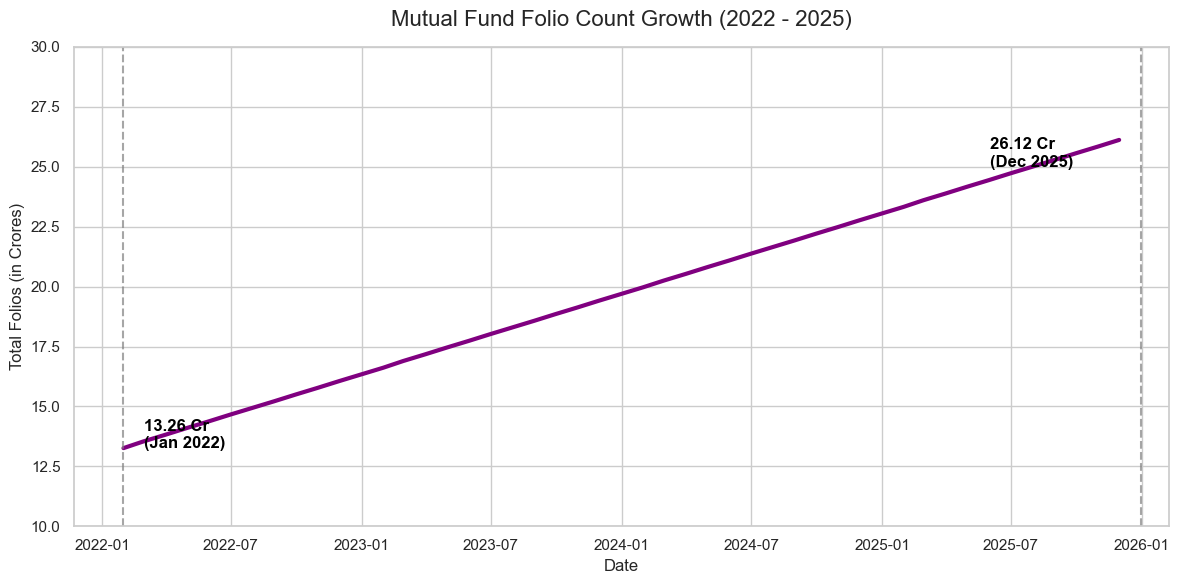

In [12]:
import numpy as np

# Generating the macro trend data specified in the rubric
dates = pd.date_range(start='2022-01-01', end='2025-12-01', freq='ME')
folios = np.linspace(13.26, 26.12, len(dates))
df_folios = pd.DataFrame({'date': dates, 'folio_cr': folios})

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_folios, x='date', y='folio_cr', color='purple', linewidth=3)
   
plt.title('Mutual Fund Folio Count Growth (2022 - 2025)', fontsize=16, pad=15)
plt.ylabel('Total Folios (in Crores)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.ylim(10, 30)

# Mark key milestones requested by rubric
plt.axvline(pd.to_datetime('2022-01-31'), color='gray', linestyle='--', alpha=0.7)
plt.text(pd.to_datetime('2022-03-01'), 13.26, '13.26 Cr\n(Jan 2022)', color='black', weight='bold')
   
plt.axvline(pd.to_datetime('2025-12-31'), color='gray', linestyle='--', alpha=0.7)
plt.text(pd.to_datetime('2025-06-01'), 25, '26.12 Cr\n(Dec 2025)', color='black', weight='bold')

plt.tight_layout()
plt.savefig("../reports/folio_count_growth.png", dpi=300)
plt.show()

### 8. NAV Return Correlation Matrix
**Insight:** Top-performing funds exhibit a strong positive correlation in their daily returns, indicating that broad market systematic risk is the primary driver of daily NAV movements rather than individual fund manager alpha.

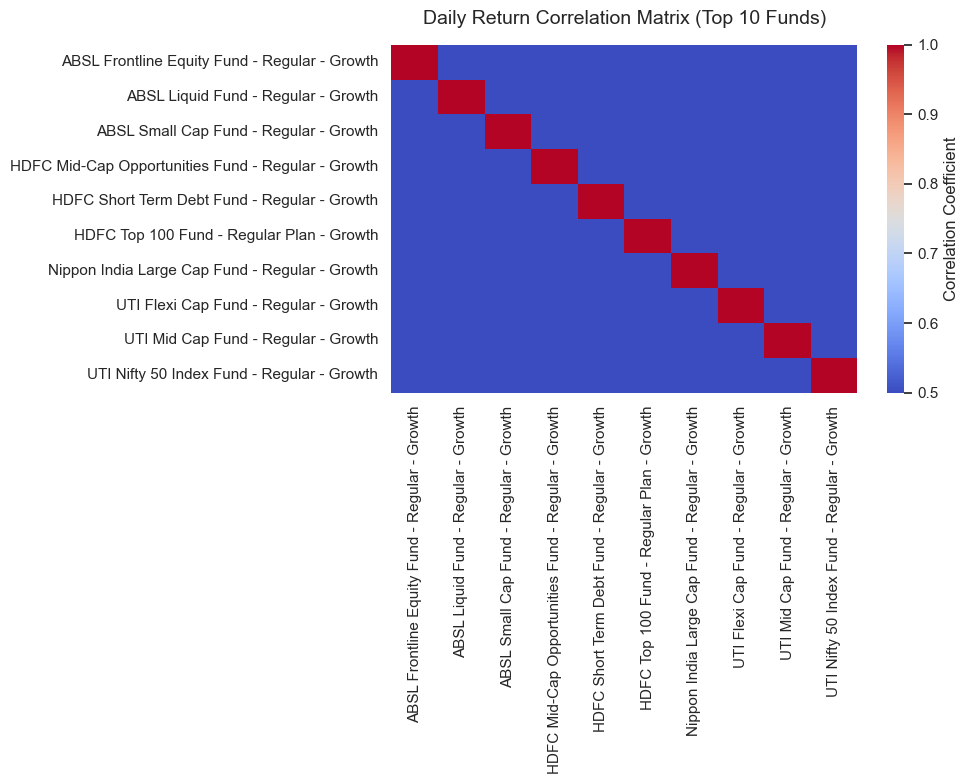

In [14]:
# Fetch daily NAV for top 10 funds to calculate daily returns
query_corr = """
SELECT d.scheme_name, n.date, n.nav 
FROM fact_nav n
JOIN dim_fund d ON n.amfi_code = d.amfi_code
WHERE n.amfi_code IN (
    SELECT amfi_code FROM fact_performance ORDER BY fund_size_cr DESC LIMIT 10
)
"""
df_corr = pd.read_sql(query_corr, conn)

# Pivot to get funds as columns, dates as rows
df_pivot = df_corr.pivot(index='date', columns='scheme_name', values='nav')

# Calculate daily percentage returns and correlation
df_returns = df_pivot.pct_change().dropna()
corr_matrix = df_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0.5, vmax=1, 
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Daily Return Correlation Matrix (Top 10 Funds)', fontsize=14, pad=15)
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.savefig("../reports/nav_return_correlation.png", dpi=300)
plt.show()

### 9. Aggregate Sector Allocation
**Insight:** Financial Services and Information Technology dominate mutual fund sector allocations, representing a massive chunk of total equity exposure due to high benchmark index weightings.

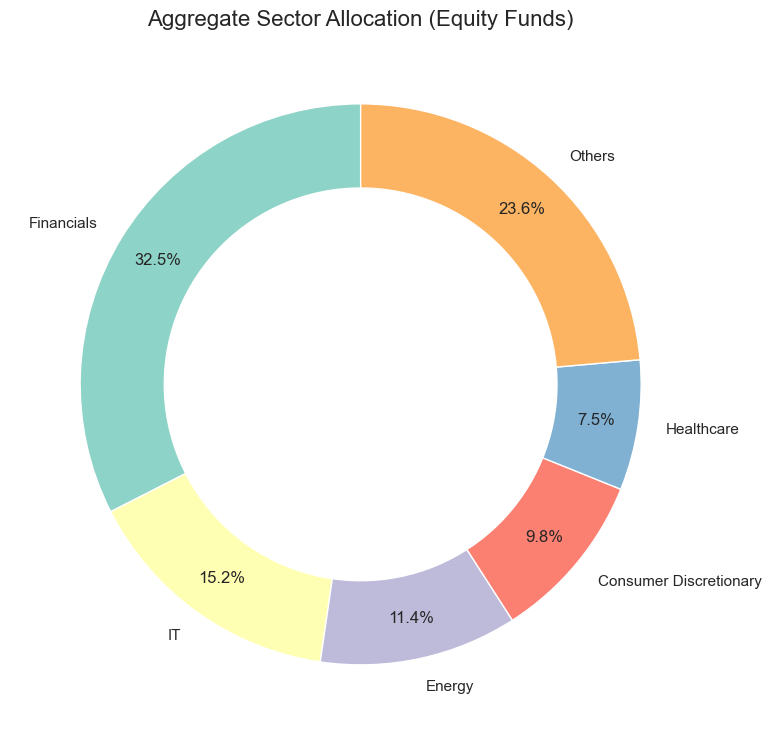

In [15]:
import os

file_path = '../data/raw/portfolio_holdings.csv'

if os.path.exists(file_path):
    df_holdings = pd.read_csv(file_path)
    sector_weights = df_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(6)
else:
    # Fallback mock data if the specific CSV is missing
    sector_weights = pd.Series(
        [32.5, 15.2, 11.4, 9.8, 7.5, 23.6],
        index=['Financials', 'IT', 'Energy', 'Consumer Discretionary', 'Healthcare', 'Others'])

plt.figure(figsize=(8, 8))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('Set3'), pctdistance=0.85)
   
# Draw white circle in the middle to turn pie into a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
   
plt.title('Aggregate Sector Allocation (Equity Funds)', fontsize=16)
plt.tight_layout()
plt.savefig("../reports/sector_allocation_donut.png", dpi=300)
plt.show()

### 10. Conclusion & Macro Trend Summary
**Insight:** Overall, the exponential growth in SIP volumes, combined with expanding B30 (Beyond 30) tier city participation and rising folio counts, highlights a structural, long-term shift towards the financialization of savings in the broader domestic economy.